In [32]:
from symfit import parameters, variables, sin, cos, Fit
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [33]:
df3= pd.read_csv('freq_x_rot.csv', header = 0)

x = df3['angle']
x = x*np.pi/180
y_sx = df3['fre_sum']/1E3
y_dx = df3['freq_diff']/1E6
y_1Dx = df3['freq_1D']/1E6 #freq of |1> -> |0>
y_2Dx = df3['freq_2D']/1E6 #freq of |0> -> |-1>

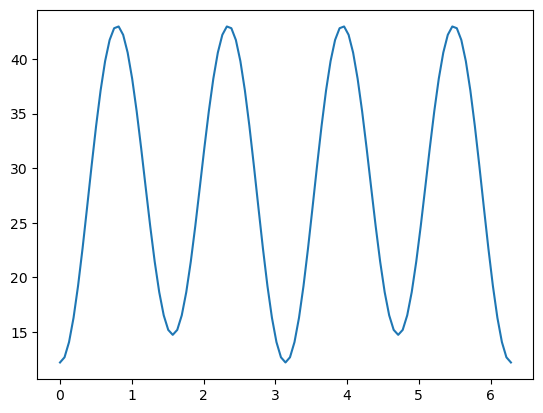

In [34]:
plt.plot(x,y_sx)

In [35]:
#fitting functions
def Hcsa1(theta,A1, B1, C1):
    
    freq_csa1 = A1 + B1*np.cos(2*theta*np.pi/180) + C1*np.sin(2*theta*np.pi/180)
    return freq_csa1

def HQ2 (theta,A1, B1, C1, D1, E1):
    freq_Q2 = A1 + B1*np.cos(2*theta*np.pi/180) + C1*np.sin(2*theta*np.pi/180) + D1*np.cos(4*theta*np.pi/180) + E1*np.sin(4*theta*np.pi/180) 
    return freq_Q2

In [30]:

def fourier_series(x, f, n=0):
    """
    Returns a symbolic fourier series of order `n`.

    :param n: Order of the fourier series.
    :param x: Independent variable
    :param f: Frequency of the fourier series
    """
    # Make the parameter objects for all the terms
    a0, *cos_a = parameters(','.join(['a{}'.format(i) for i in range(0, n + 1)]))
    sin_b = parameters(','.join(['b{}'.format(i) for i in range(1, n + 1)]))
    # Construct the series
    series = a0 + sum(ai * cos(i * f * x ) + bi * sin(i * f * x )
                     for i, (ai, bi) in enumerate(zip(cos_a, sin_b), start=1))
    return series

x, y = variables('x, y')
w, = parameters('w')
model_dict = {y: fourier_series(x, f=w, n=3)}
print(model_dict)



{y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + a3*cos(3*w*x) + b1*sin(w*x) + b2*sin(2*w*x) + b3*sin(3*w*x)}


/usr/local/lib/python3.10/dist-packages/symfit/core/objectives.py:350: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  pre_sum = jac_comp * ((y - f) / sigma**2)[np.newaxis, ...]



Parameter Value        Standard Deviation
a0        2.824642e+01 8.903801e-14
a1        -1.264300e+00 1.323209e-13
a2        -1.475996e+01 1.222036e-13
a3        4.757577e-13 1.262372e-13
b1        5.592728e-13 1.235734e-13
b2        3.195686e-15 2.725540e-13
b3        -8.020801e-15 1.231338e-13
w         2.000000e+00 2.621899e-15
Status message         Optimization terminated successfully.
Number of iterations   29
Objective              <symfit.core.objectives.LeastSquares object at 0x7fab9e3468f0>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7fab9e4350c0>

Goodness of fit qualifiers:
chi_squared            7.050298558917508e-23
objective_value        3.525149279458754e-23
r_squared              1.0


/usr/local/lib/python3.10/dist-packages/symfit/core/objectives.py:382: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  p1 = hess_comp * ((y - f) / sigma**2)[np.newaxis, np.newaxis, ...]


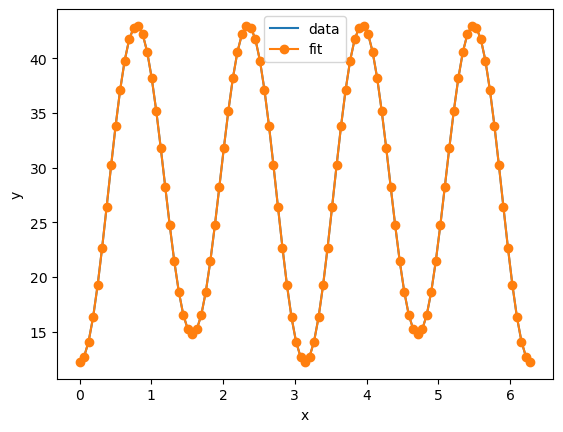

In [39]:
# Make step function data
# xdata = np.linspace(-np.pi, np.pi)
# ydata = np.zeros_like(xdata)
# ydata[xdata > 0] = 1
xdata = x
ydata = y_sx
# ydata[xdata > 0] = 1
# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result = fit.execute()
print(fit_result)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result.params).y, marker="o", label = "fit")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(title="\n".join(fit_pa))
plt.show()

In [42]:
print(fit_result.params)

OrderedDict([('a0', 28.246416757877657), ('a1', -1.2643001806268763), ('a2', -14.759960430984489), ('a3', 4.757577474241789e-13), ('b1', 5.592728444439744e-13), ('b2', 3.1956859362976095e-15), ('b3', -8.020800626129536e-15), ('w', 2.0000000000000004)])


In [13]:
print(ydata)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]
